# Ejercicios: modelos de regresión (RL, RP, RF)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

In [2]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])

df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


In [3]:
def entrenar_y_comparar_modelos(df_hist, variable, titulo, entidad, anio_final=2100):
    X = df_hist[["Year"]]
    y = df_hist[variable]

    ultimo_anio = int(df_hist["Year"].max())
    anios_futuros = np.arange(ultimo_anio + 1, anio_final + 1).reshape(-1, 1)
    X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

    modelo_lineal = LinearRegression()
    modelo_lineal.fit(X, y)
    pred_lineal_hist = modelo_lineal.predict(X)
    pred_lineal_futuro = modelo_lineal.predict(X_futuro)

    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X)
    X_futuro_poly = poly.transform(X_futuro)

    modelo_polinomial = LinearRegression()
    modelo_polinomial.fit(X_poly, y)
    pred_poli_hist = modelo_polinomial.predict(X_poly)
    pred_poli_futuro = modelo_polinomial.predict(X_futuro_poly)

    modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    modelo_rf.fit(X, y)
    pred_rf_hist = modelo_rf.predict(X)
    pred_rf_futuro = modelo_rf.predict(X_futuro)

    plt.figure(figsize=(14, 7))
    plt.scatter(df_hist["Year"], y, label="Datos históricos", alpha=0.5)

    plt.plot(df_hist["Year"], pred_lineal_hist, color="tab:orange", alpha=0.6)
    plt.plot(anios_futuros.flatten(), pred_lineal_futuro, color="tab:orange",
              linestyle="--", label="Regresión lineal")

    plt.plot(df_hist["Year"], pred_poli_hist, color="tab:green", alpha=0.6)
    plt.plot(anios_futuros.flatten(), pred_poli_futuro, color="tab:green",
              linestyle="--", label="Regresión polinomial")

    plt.plot(df_hist["Year"], pred_rf_hist, color="tab:red", alpha=0.6)
    plt.plot(anios_futuros.flatten(), pred_rf_futuro, color="tab:red",
              linestyle="--", label="Random Forest")

    plt.title(f"{titulo} - {entidad}")
    plt.xlabel("Año")
    plt.ylabel(titulo)
    plt.ticklabel_format(style="plain", axis="y", useOffset=False)
    plt.legend()
    plt.grid()
    plt.show()

## 1. Extraer el país China

In [4]:
df_china = df[df["Entity"] == "China"]

ultimo_historico_china = df_china.loc[df_china["births_estimates"].notna(), "Year"].max()
df_china_historico = df_china[df_china["Year"] <= ultimo_historico_china]

df_china_historico.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
7097,China,CHN,1950,12564023.0,NaN,22293376.0,NaN,22293376.0,12564023.0
7098,China,CHN,1951,12411701.0,NaN,22144814.0,NaN,22144814.0,12411701.0
7099,China,CHN,1952,12459848.0,NaN,25496318.0,NaN,25496318.0,12459848.0
7100,China,CHN,1953,12309525.0,NaN,24139416.0,NaN,24139416.0,12309525.0
7101,China,CHN,1954,12145578.0,NaN,25438544.0,NaN,25438544.0,12145578.0


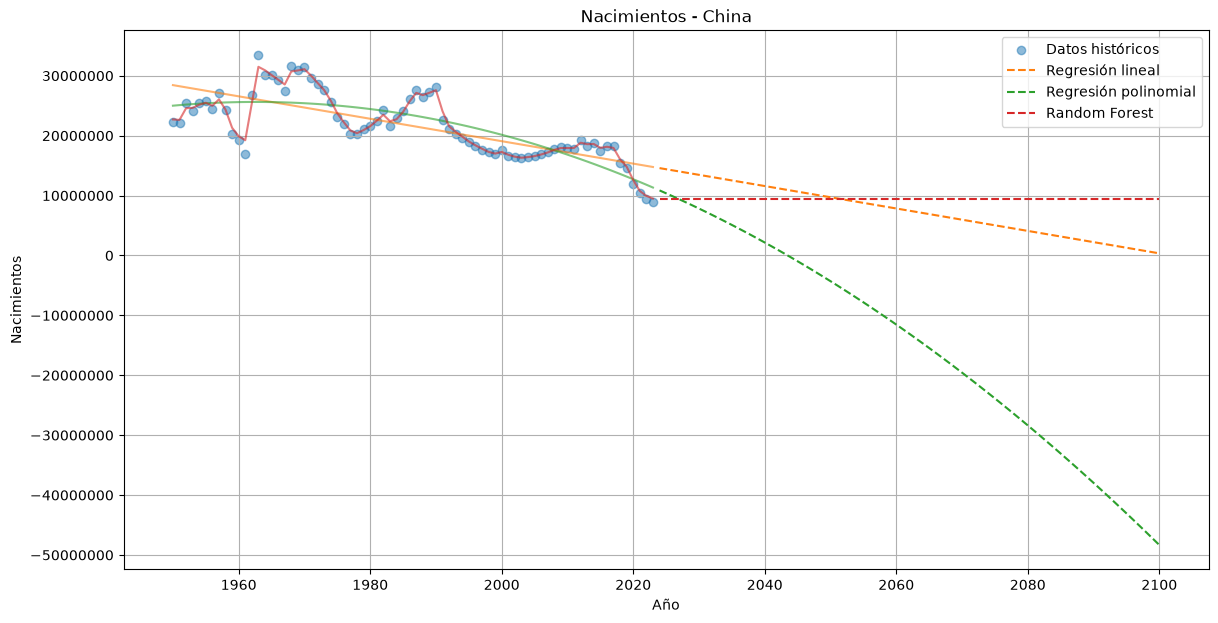

In [5]:
entrenar_y_comparar_modelos(df_china_historico, "births", "Nacimientos", "China")

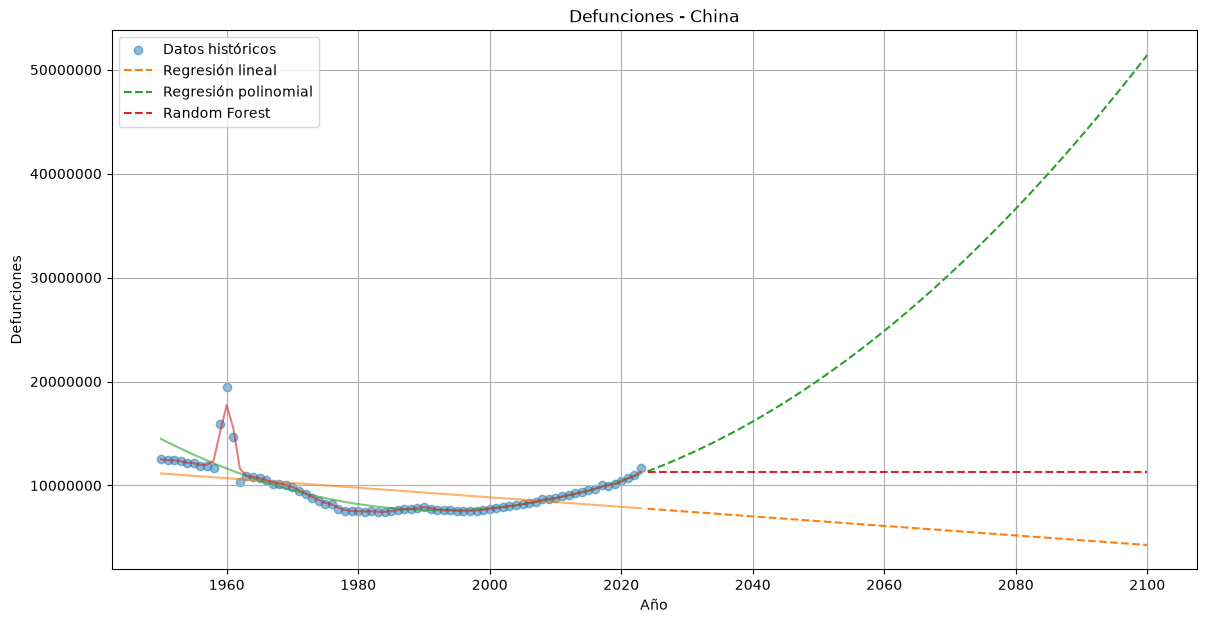

In [6]:
entrenar_y_comparar_modelos(df_china_historico, "deaths", "Defunciones", "China")

## 2. Nacimientos / defunciones a partir de 1980 en México

In [7]:
df_mexico = df[df["Entity"] == "Mexico"]

ultimo_historico_mx = df_mexico.loc[df_mexico["births_estimates"].notna(), "Year"].max()
df_mexico_historico = df_mexico[df_mexico["Year"] <= ultimo_historico_mx]

df_mexico_1980 = df_mexico_historico[df_mexico_historico["Year"] >= 1980]

df_mexico_1980.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22831,Mexico,MEX,1980,464115.0,NaN,2357249.0,NaN,2357249.0,464115.0
22832,Mexico,MEX,1981,461670.0,NaN,2366047.0,NaN,2366047.0,461670.0
22833,Mexico,MEX,1982,462853.0,NaN,2384613.0,NaN,2384613.0,462853.0
22834,Mexico,MEX,1983,465775.0,NaN,2404958.0,NaN,2404958.0,465775.0
22835,Mexico,MEX,1984,470587.0,NaN,2431036.0,NaN,2431036.0,470587.0


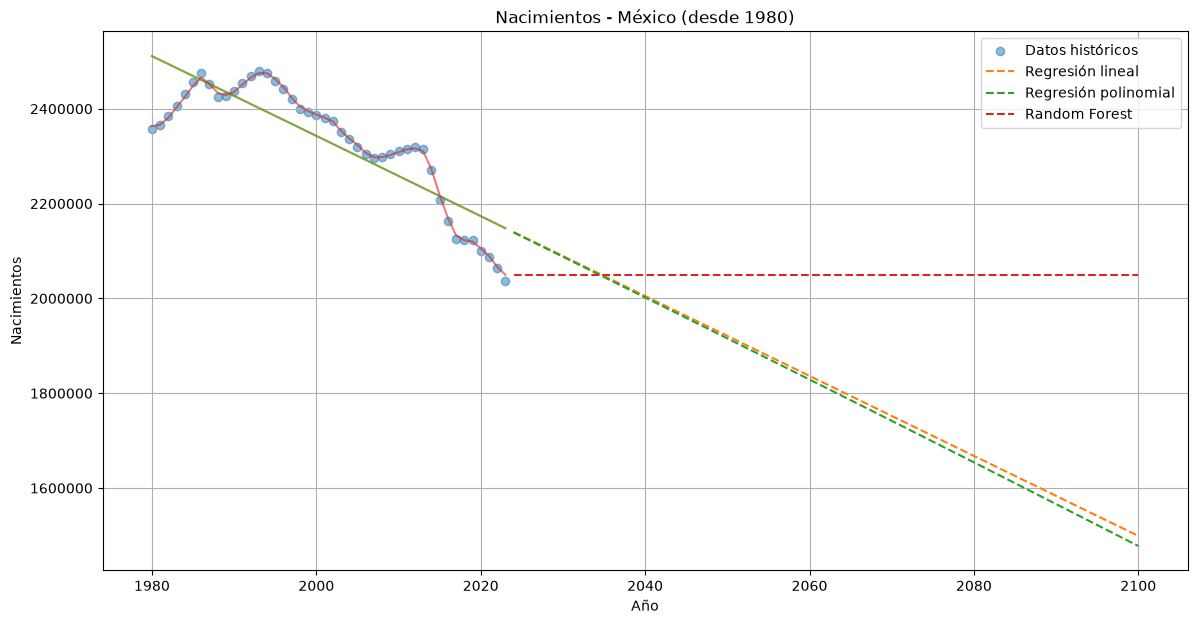

In [8]:
entrenar_y_comparar_modelos(df_mexico_1980, "births", "Nacimientos", "México (desde 1980)")

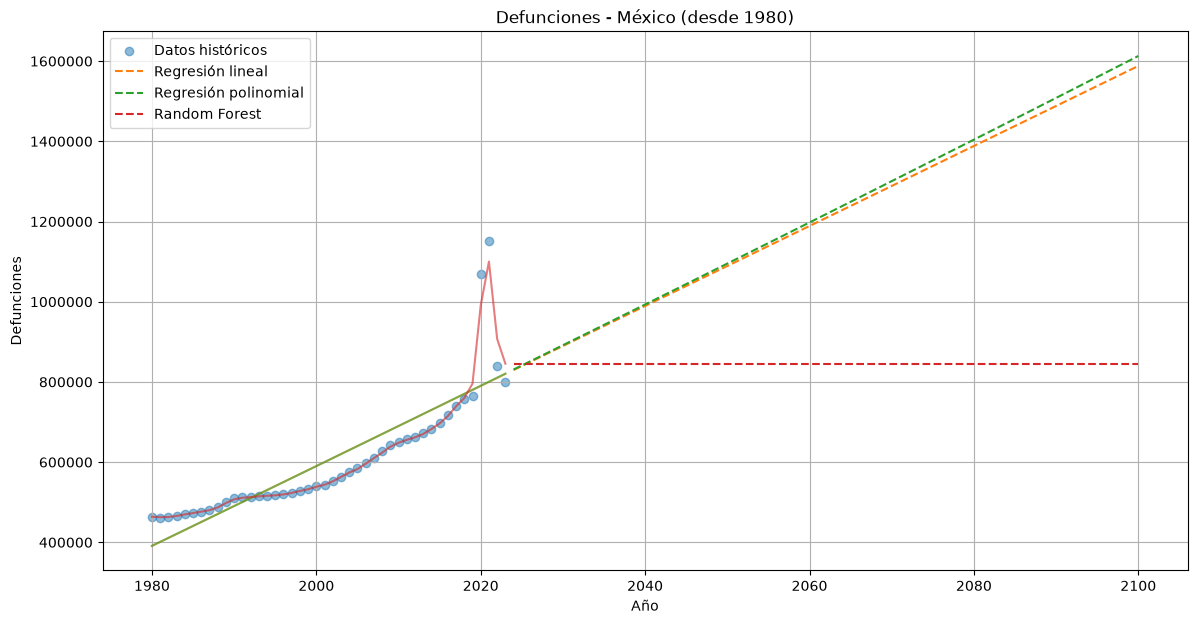

In [9]:
entrenar_y_comparar_modelos(df_mexico_1980, "deaths", "Defunciones", "México (desde 1980)")

## 3. Nacimientos / defunciones a partir de 2000 en México

In [10]:
df_mexico_2000 = df_mexico_historico[df_mexico_historico["Year"] >= 2000]

df_mexico_2000.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22851,Mexico,MEX,2000,540567.0,NaN,2385977.0,NaN,2385977.0,540567.0
22852,Mexico,MEX,2001,543803.0,NaN,2380261.0,NaN,2380261.0,543803.0
22853,Mexico,MEX,2002,553391.0,NaN,2374140.0,NaN,2374140.0,553391.0
22854,Mexico,MEX,2003,563140.0,NaN,2351177.0,NaN,2351177.0,563140.0
22855,Mexico,MEX,2004,575925.0,NaN,2335226.0,NaN,2335226.0,575925.0


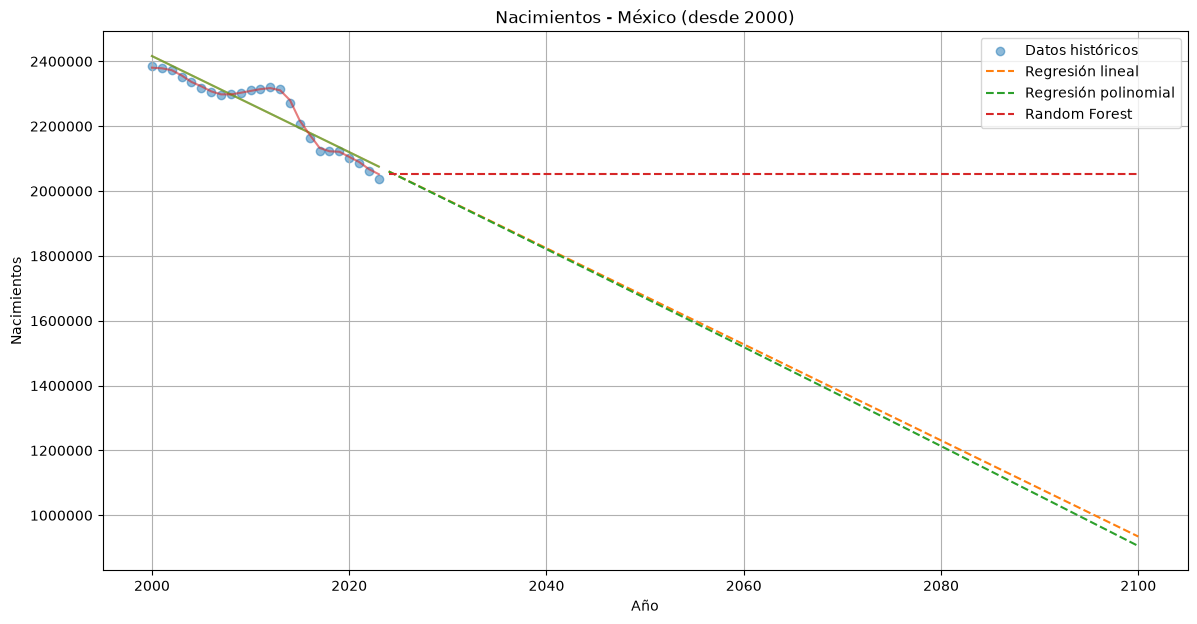

In [11]:
entrenar_y_comparar_modelos(df_mexico_2000, "births", "Nacimientos", "México (desde 2000)")

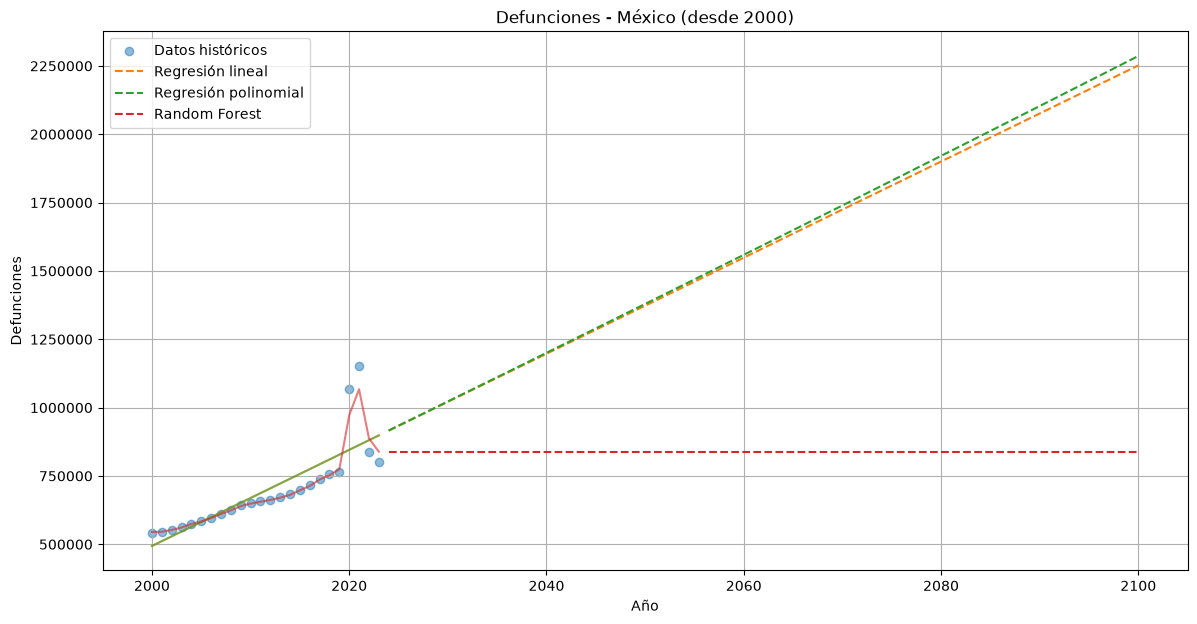

In [12]:
entrenar_y_comparar_modelos(df_mexico_2000, "deaths", "Defunciones", "México (desde 2000)")